# Tutorial 10: Reinforcement Learning Tutorial
# Part C: RL Controller Testing (Soft-Actor Critic)

# Step 1 - Imports & Model Path

In [22]:
import os
import sys
from pathlib import Path

# Project root = parent folder of the current working directory (repo root)
project_root = Path.cwd().resolve().parent

# Add project root to Python path so we can import local modules like `src/...`
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from stable_baselines3 import SAC          # RL algorithm (Soft Actor-Critic) from SB3
from src.env_wrapper import MuFlex         # MuFlex environment (project code)

In [23]:
# Path to the FMU (building simulation model)
fmu_path = project_root / "models" / "small_office" / "small_baseline_v1.fmu"

# Path to the trained SB3 model
model_path = project_root / "Tutorial_MuFlex" / "RL_Log" / "SAC_small_office.zip"

# Print paths 
print("project_root:", project_root)
print("fmu_path:", fmu_path)
print("model_path:", model_path)

# Verify files exist before running
print("FMU exists:", fmu_path.exists())
print("Model exists:", model_path.exists())

project_root: C:\Users\Administrator\Desktop\code\MuFlex_tutorial
fmu_path: C:\Users\Administrator\Desktop\code\MuFlex_tutorial\models\small_office\small_baseline_v1.fmu
model_path: C:\Users\Administrator\Desktop\code\MuFlex_tutorial\Tutorial_MuFlex\RL_Log\SAC_small_office.zip
FMU exists: True
Model exists: True


# Step 2 - Create Environment

In [18]:
# Load Small Office Model
fmu_configs = [{"io_type": "OfficeS", "path": str(fmu_path)}]

# Create MuFlex environment for a 1-day evaluation run (15-min steps)
env = MuFlex(
    fmu_configs=fmu_configs,
    sim_days=1,
    start_date=201,
    step_size=900,
    action_type="continuous",
    include_hour=False,
    reward_mode="default",
    max_total_hvac_power=9000.0,
    save_results=True,    # Save outputs for later checking
    print_step_info=True  # Print step info for debugging
)


# Step 3 - Load Trained Model

In [25]:
# Load the trained SAC agent and attach it to this env
model = SAC.load(model_path, env=env)
# Quick check that loading succeeded
print("Model loaded:", type(model))

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Model loaded: <class 'stable_baselines3.sac.sac.SAC'>


# Step 4 - Run one evaluation episode

In [26]:
# Reset env to start the episode (one day) and get the initial observation
obs, _ = env.reset(seed=42)

done = False                  # Episode finished flag
total_reward = 0.0            # Accumulate total episode reward
steps = 0                     # Count how many simulation steps we ran

# Loop until the env signals termination/truncation
while not done:
    # Get action from the trained policy (deterministic = use mean action)
    action, _ = model.predict(obs, deterministic=True)

    # Apply action to the env and receive next observation and reward
    obs, reward, terminated, truncated, _ = env.step(action)
    # Episode ends if either terminated (natural end) or truncated (time limit, etc.)
    done = terminated or truncated

    # Track episode reward and step count
    total_reward += float(reward)
    steps += 1

# Close env to release FMU/simulator resources
env.close()
# Print a short summary of this evaluation run
print(f"July 20 Test finished. Steps={steps}, Total Reward={total_reward:.3f}")

 Saving results is enabled. 
 [Init] Loading FMU #1: io_type = OfficeS, path = C:\Users\Administrator\Desktop\code\MuFlex_tutorial\models\small_office\small_baseline_v1.fmu 
 [Init] Initializing FMU #1, time range = (17280000, 17366400) 
 -------------------------------------------------- 
 [Step Info] Step: 0 
   Global Action (raw input): [ 0.08208871  0.69142556  0.2511289  -0.96914387  0.60771227 -0.9713975 ] 
   Global Action (physical values): [[24.1, 24.700000000000003, 24.3, 23.0, 24.6, 10.100000000000001]] 
   FMU 1 raw output: [30.075     0.        0.        0.        0.       30.15365  25.902157
 26.808279 26.699978 26.749666 27.08617   0.25    ] 
   FMU 1 physical action: [24.1, 24.700000000000003, 24.3, 23.0, 24.6, 10.100000000000001] 
   Next state (normalized): [0.8475     0.7509375  0.         0.         0.         0.
 0.603073   0.51804316 0.5361656  0.53399956 0.53499335 0.54172343
 0.01666667] 
   Reward: -0.0 
 -------------------------------------------------- 
 [S

# Step 4 - Benchmark RL & Baseline Controller Performance

## Step 5.1 - Plots of RL & Baseline Performance (HVAC Power)

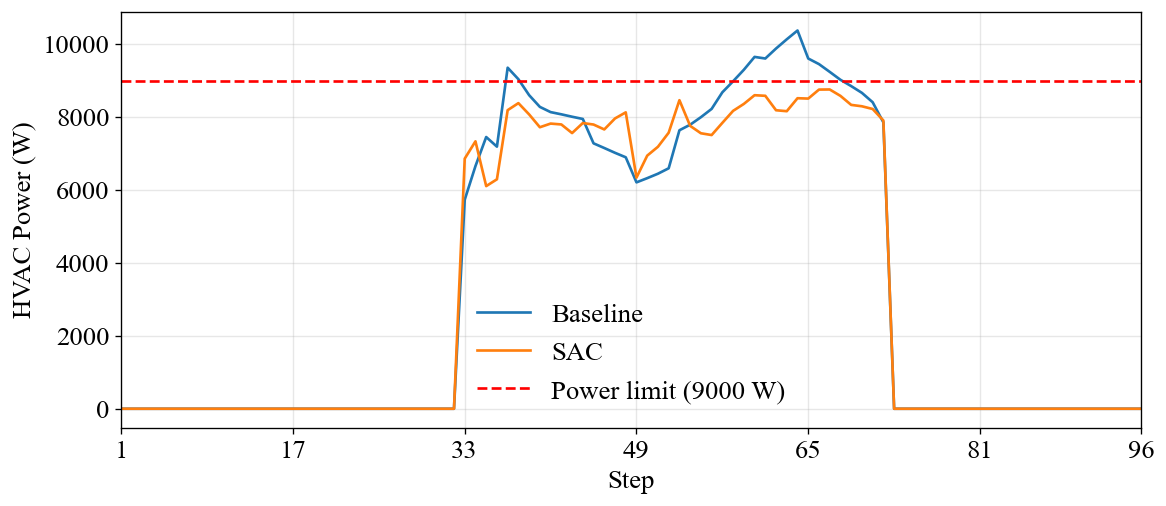

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Load two runs (Baseline vs SAC) ---
path_baseline = r"C:\Users\Administrator\Desktop\code\MuFlex_tutorial\Tutorial_MuFlex\simulation_data_20260127_065906\fmu_1_data.xlsx"
path_sac      = r"C:\Users\Administrator\Desktop\code\MuFlex_tutorial\Tutorial_MuFlex\simulation_data_20260127_100932\fmu_1_data.xlsx"

df_base = pd.read_excel(path_baseline)
df_sac  = pd.read_excel(path_sac)

# --- 2) Keep only the first 96 steps (1 day) ---
df_base = df_base.iloc[:96].copy()
df_sac  = df_sac.iloc[:96].copy()

# --- 3) Compute HVAC power (coil + fan) ---
hvac_base = df_base["coilPower"] + df_base["fanPower"]
hvac_sac  = df_sac["coilPower"] + df_sac["fanPower"]

# --- 4) X-axis starts from 1 ---
step_base = df_base["Step"] + 1
step_sac  = df_sac["Step"] + 1

# --- 5) Plot settings ---
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
plt.figure(figsize=(10, 4.5), dpi=120)

# --- 6) Plot two curves ---
plt.plot(step_base, hvac_base, linewidth=1.6, label="Baseline")
plt.plot(step_sac,  hvac_sac,  linewidth=1.6, label="SAC")

# Power limit line
plt.axhline(9000, linestyle="--", linewidth=1.6, color="red", label="Power limit (9000 W)")

# Axis labels and limits
plt.xlabel("Step")
plt.ylabel("HVAC Power (W)")
plt.xlim(1, 96)

# Custom x ticks (every 4 hours if step_size = 15 min)
ticks = list(range(1, 94, 16)) + [96]
plt.xticks(ticks)

# Grid, legend, and layout
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## Step 5.2 - Plots of RL & Baseline Performance (Zone Temperature)

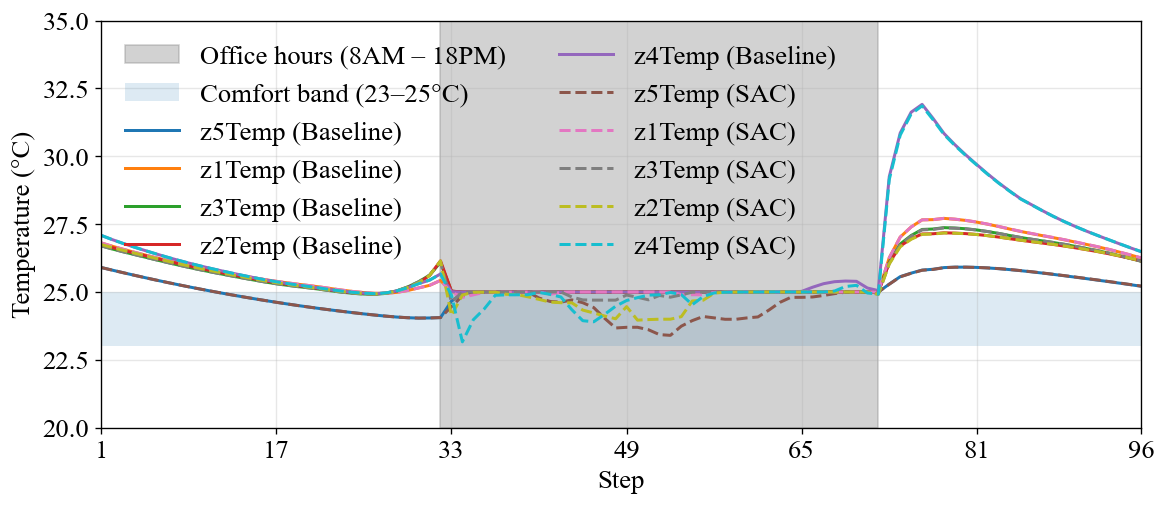

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Paths to the two runs (Baseline vs SAC)
path_baseline = r"C:\Users\Administrator\Desktop\code\MuFlex_tutorial\Tutorial_MuFlex\simulation_data_20260127_065906\fmu_1_data.xlsx"
path_sac      = r"C:\Users\Administrator\Desktop\code\MuFlex_tutorial\Tutorial_MuFlex\simulation_data_20260127_100932\fmu_1_data.xlsx"

# Load both Excel files
df_base = pd.read_excel(path_baseline)  # change file name here
df_sac  = pd.read_excel(path_sac)       # change file name here

# Keep only the first 96 steps (96 * 15 min = 1 day)
df_base = df_base.iloc[:96].copy()
df_sac  = df_sac.iloc[:96].copy()

# Shift step index by +1 so the x-axis starts at 1 instead of 0
step_base = df_base["Step"] + 1
step_sac  = df_sac["Step"] + 1

# Plot style settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
plt.figure(figsize=(10, 4.5), dpi=120)

# Highlight office hours region (8:00–18:00)
# With 15-min steps: 8:00 -> step 32, 18:00 -> step 72
plt.axvspan(32, 72, color="grey", alpha=0.35, label="Office hours (8AM – 18PM)")

# Comfort band (23–25°C)
plt.axhspan(23, 25, alpha=0.15, label="Comfort band (23–25°C)")

# Plot zone temperatures (Baseline)
for col in ["z5Temp", "z1Temp", "z3Temp", "z2Temp", "z4Temp"]:
    plt.plot(step_base, df_base[col], linewidth=1.8, label=f"{col} (Baseline)")

# Plot zone temperatures (SAC)
for col in ["z5Temp", "z1Temp", "z3Temp", "z2Temp", "z4Temp"]:
    plt.plot(step_sac, df_sac[col], linewidth=1.8, linestyle="--", label=f"{col} (SAC)")

# Axis labels and limits
plt.xlabel("Step")
plt.ylabel("Temperature (°C)")
plt.xlim(1, 96)

# Custom x ticks (roughly every 4 hours if step_size = 15 min)
ticks = list(range(1, 94, 16)) + [96]
plt.xticks(ticks)

# Y-axis range
plt.ylim(20, 35)

# Grid, legend, and layout
plt.grid(True, alpha=0.3)
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

## Step 5.3 - Plots of RL & Baseline Performance (Reward)

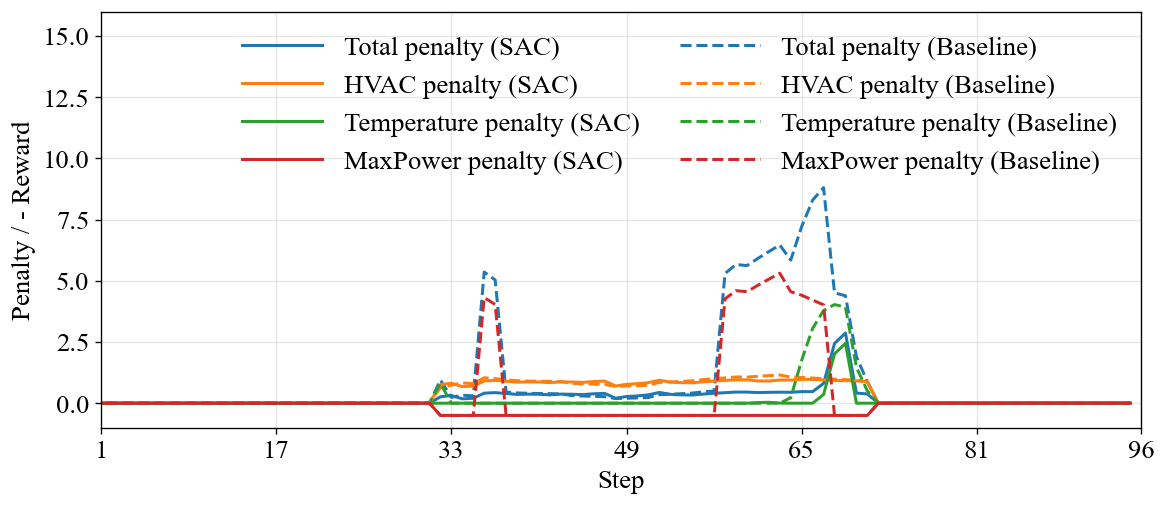

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Paths to the two runs (Baseline vs SAC)
path_baseline = r"C:\Users\Administrator\Desktop\code\MuFlex_tutorial\Tutorial_MuFlex\simulation_data_20260127_065906\rewards.xlsx"
path_sac      = r"C:\Users\Administrator\Desktop\code\MuFlex_tutorial\Tutorial_MuFlex\simulation_data_20260127_100932\rewards.xlsx"

# Load both reward files
df_base = pd.read_excel(path_baseline).iloc[:96].copy()
df_sac  = pd.read_excel(path_sac).iloc[:96].copy()

# X-axis: Step
step_base = df_base["Step"]
step_sac  = df_sac["Step"]

# Penalties (Baseline)
hvac_base  = df_base["HVAC_penalty"]
temp_base  = df_base["Temperature_penalty"]
maxp_base  = df_base["MaxPower_penalty"]
total_base = hvac_base + temp_base + maxp_base

# Penalties (SAC)
hvac_sac  = df_sac["HVAC_penalty"]
temp_sac  = df_sac["Temperature_penalty"]
maxp_sac  = df_sac["MaxPower_penalty"]
total_sac = hvac_sac + temp_sac + maxp_sac

# Plot style settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
plt.figure(figsize=(10, 4.5), dpi=120)

# Total penalty: same color, thicker
line_total_sac,  = plt.plot(step_sac,  total_sac,  linewidth=1.8, linestyle="-",  label="Total penalty (SAC)")
line_total_base, = plt.plot(step_base, total_base, linewidth=1.8, linestyle="--",
                            color=line_total_sac.get_color(), label="Total penalty (Baseline)")

# HVAC penalty: same color (SAC solid, Baseline dashed)
line_hvac_sac, = plt.plot(step_sac, hvac_sac, linewidth=1.8, linestyle="-", label="HVAC penalty (SAC)")
line_hvac_base, = plt.plot(step_base, hvac_base, linewidth=1.8, linestyle="--",
                           color=line_hvac_sac.get_color(), label="HVAC penalty (Baseline)")

# Temperature penalty
line_temp_sac, = plt.plot(step_sac, temp_sac, linewidth=1.8, linestyle="-", label="Temperature penalty (SAC)")
line_temp_base, = plt.plot(step_base, temp_base, linewidth=1.8, linestyle="--",
                           color=line_temp_sac.get_color(), label="Temperature penalty (Baseline)")

# MaxPower penalty
line_maxp_sac, = plt.plot(step_sac, maxp_sac, linewidth=1.8, linestyle="-", label="MaxPower penalty (SAC)")
line_maxp_base, = plt.plot(step_base, maxp_base, linewidth=1.8, linestyle="--",
                           color=line_maxp_sac.get_color(), label="MaxPower penalty (Baseline)")

plt.xlabel("Step")
plt.ylabel("Penalty / - Reward")

# X-axis formatting (1 day = 96 steps)
plt.xlim(1, 96)
ticks = list(range(1, 94, 16)) + [96]
plt.xticks(ticks)

# Fix y-axis range
plt.ylim(-1, 16)

plt.grid(True, alpha=0.3)

# Legend: SAC one column, Baseline one column
handles = [
    line_total_sac, line_hvac_sac, line_temp_sac, line_maxp_sac,
    line_total_base, line_hvac_base, line_temp_base, line_maxp_base
]
labels = [h.get_label() for h in handles]
plt.legend(handles, labels, frameon=False, ncol=2, columnspacing=1.5, handlelength=3.0)

plt.tight_layout()
plt.show()